<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 06</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Baselines</div><div style="font-size:1.05em;opacity:0.85">How far customer-base models get — and what trusting them costs.</div></div>

Before any supervised model, two baselines that need no training labels: a **cadence rule**
(how many cycles late is the customer?) and the **BG/NBD** model, the standard probabilistic
model of non-contractual customers. Both are calibrated on the calibration cutoff and judged on
the test cutoff twice: by how well they *rank* customers, and by how much money a retention
campaign built on them would *make*. The second judgement is the one the business cares about,
and it is where calibration stops being a technicality.

**Pipeline rule.** The numbers come from the pipeline: `churnvalue evaluate-baselines` writes
`reports/baseline_evaluation.json`, and this notebook reads it. Probabilities for the charts are
recomputed with the same package functions (`churnvalue.evaluate`, `churnvalue.calibration`,
`churnvalue.economics`); nothing is re-implemented here.

| | |
|---|---|
| **Input** | `data/interim/snapshots.parquet` · `reports/baseline_evaluation.json` |
| **Outputs** | `reports/results/06_summary.json` · `reports/figures/06_*.png` |
| **Parameters** | `configs/default.yaml` → `economics` (margin 0.35, λc 0.10, λa 10, γ 0.30, c £1, T 365 d), `evaluation` |
| **Shared code** | `churnvalue.btyd` · `churnvalue.economics` · `churnvalue.calibration` · `churnvalue.evaluate` · `churnvalue.metrics` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">B1 BG/NBD</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">B2 value at risk</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">B3 the economics</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">B4 ranking</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">B5 calibration</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">B6 money</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import precision_recall_curve

from churnvalue.btyd import fit_bgnbd
from churnvalue.calibration import select_calibrator
from churnvalue.config import load_config, project_root
from churnvalue.economics import (
    break_even_limit,
    break_even_probability,
    customer_economics,
    value_at_risk,
)
from churnvalue.evaluate import BASELINE_SCORERS
from churnvalue.features import compute_base_features
from churnvalue.reporting import StageSummary
from churnvalue.snapshots import bgnbd_inputs, make_cutoffs
from churnvalue.splits import make_temporal_split
from churnvalue.viz import style
from churnvalue.viz.style import (
    CHURN,
    INK,
    MODEL_COLORS,
    MUTED,
    NEUTRAL,
    ORACLE_COLOR,
    RETAINED,
    SEQUENTIAL,
)

os.chdir(project_root())
CFG = load_config()
SNAP, ECON, EV = CFG.snapshots, CFG.economics, CFG.evaluation
H = SNAP.horizon_days
STAGE, FIGURES, RESULTS = "06", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


tx = pd.read_parquet(CFG.data.interim_dir / "transactions.parquet")
snapshots = pd.read_parquet(CFG.data.interim_dir / "snapshots.parquet")
report = json.loads((CFG.reports_dir / "baseline_evaluation.json").read_text(encoding="utf-8"))
cutoffs = make_cutoffs(tx["date"].min(), tx["date"].max(), H, SNAP.min_history_months)
split = make_temporal_split(cutoffs, H, CFG.splits.calibration_offset_months)
cal = snapshots[snapshots["cutoff"] == split.calibration]
test = snapshots[snapshots["cutoff"] == split.test]
y_cal, y_test = cal["churn"].to_numpy(float), test["churn"].to_numpy(float)
LABELS = {"cadence_rule": "cadence rule", "bgnbd": "BG/NBD"}

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">B1 · BG/NBD</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">a customer-base model, fitted afresh at every cutoff</span></div>

BG/NBD models each customer as buying at a personal Poisson rate λ until an unobserved dropout
that can happen after any purchase with probability *p*; λ and *p* vary across customers
(gamma and beta). Fitted by maximum likelihood on every customer known at the cutoff — no churn
label is used — it yields P(alive), the probability that a customer has not dropped out yet.

Refitted at each cutoff, the **purchase rate drifts down only slowly** (about −20 % over the
period) while the **estimated dropout probability grows** from almost zero to about 6 % per
purchase: with only months of history, nobody has
visibly dropped out yet. The same customer therefore gets a different P(alive) at different
cutoffs for reasons unrelated to their behaviour — the score itself drifts, one root cause of the
calibration failure in B5.

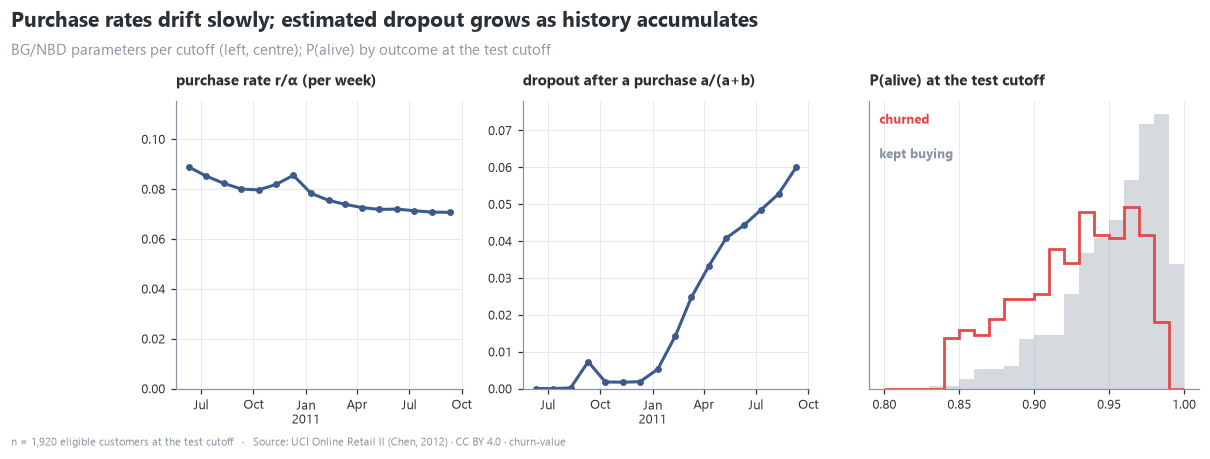

In [2]:
fits = []
for c in cutoffs:
    p = fit_bgnbd(*bgnbd_inputs(compute_base_features(tx, c, H)))
    fits.append(
        {
            "cutoff": c,
            "purchase rate r/α (per week)": p.r / p.alpha,
            "dropout after a purchase a/(a+b)": p.a / (p.a + p.b),
        }
    )
fits = pd.DataFrame(fits).set_index("cutoff")
S["bgnbd_by_cutoff"] = fits.to_dict(orient="index")
dropout = fits["dropout after a purchase a/(a+b)"]
S["dropout_first_last"] = [dropout.iloc[0], dropout.iloc[-1]]
rate = fits["purchase rate r/α (per week)"]
S["purchase_rate_first_last"] = [rate.iloc[0], rate.iloc[-1]]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), gridspec_kw={"width_ratios": [1, 1, 1.15]})
for ax, column in zip(axes[:2], fits.columns, strict=True):
    ax.plot(fits.index, fits[column], color=NEUTRAL, marker="o", markersize=3.5)
    ax.set_title(column, fontsize=9.5)
    ax.set_ylim(0, fits[column].max() * 1.3)
    style.date_axis(ax)
ax = axes[2]
bins = np.linspace(0.8, 1, 21)
for label, color in [(0, RETAINED), (1, CHURN)]:
    values = test.loc[test["churn"] == label, "p_alive"]
    ax.hist(
        values,
        bins=bins,
        density=True,
        histtype="stepfilled" if label == 0 else "step",
        color=color,
        alpha=0.4 if label == 0 else 1,
        lw=1.8,
    )
ax.set_title("P(alive) at the test cutoff", fontsize=9.5)
ax.text(0.03, 0.92, "churned", color=CHURN, fontsize=8.5, fontweight="bold", transform=ax.transAxes)
ax.text(
    0.03, 0.80, "kept buying", color=MUTED, fontsize=8.5, fontweight="bold", transform=ax.transAxes
)
ax.set_yticks([])
style.headline(
    fig,
    "Purchase rates drift slowly; estimated dropout grows as history accumulates",
    "BG/NBD parameters per cutoff (left, centre); P(alive) by outcome at the test cutoff",
)
style.add_source(fig, f"n = {len(test):,} eligible customers at the test cutoff")
save(fig, "bgnbd")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">B2 · Value at risk</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">shrink the noisy averages before pricing a customer</span></div>

The economics price each customer by *V* = margin × AOV × (T / cadence): the margin they would
bring over the next year **if they stay**. A customer's raw average order value from two or
three purchases is noisy; the Gamma-Gamma model shrinks it towards the population mean, more
strongly the fewer purchases there are. Customers on the diagonal are trusted as they are.

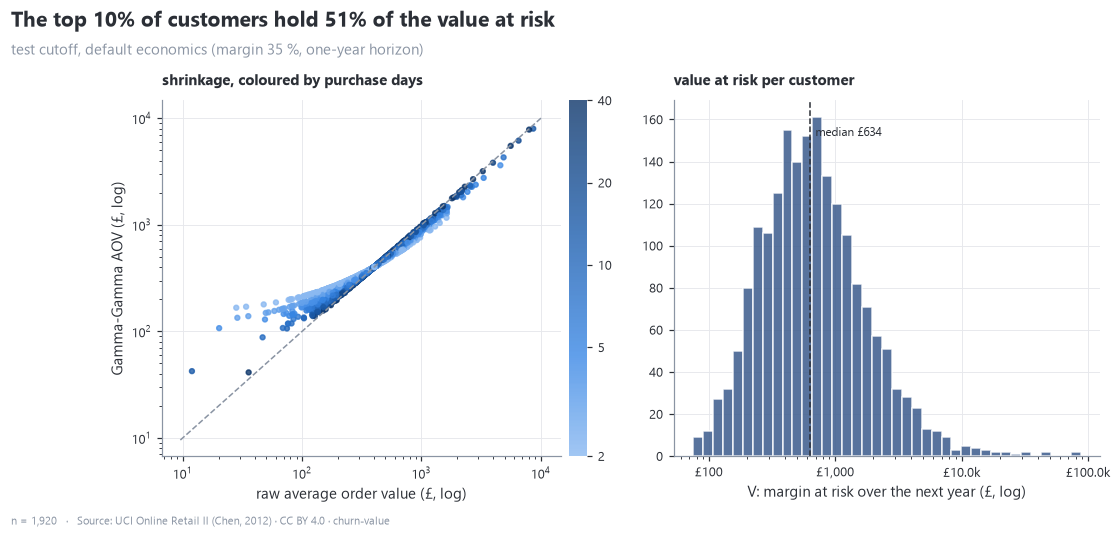

In [3]:
econ_v = value_at_risk(test["aov_gg"], test["cadence_days"], ECON)
S["v_quantiles"] = dict(
    zip(["p10", "p50", "p90", "p99"], np.percentile(econ_v, [10, 50, 90, 99]), strict=True)
)
S["v_top10pct_share"] = np.sort(econ_v)[-len(econ_v) // 10 :].sum() / econ_v.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
visible = SEQUENTIAL.from_list("visible", SEQUENTIAL(np.linspace(0.3, 1.0, 256)))
sc = ax1.scatter(
    test["avg_order_value"],
    test["aov_gg"],
    c=np.log10(test["n_purchase_days"]),
    cmap=visible,
    s=10,
    alpha=0.8,
    vmin=np.log10(2),
    vmax=np.log10(40),
)
lims = [test["avg_order_value"].min() * 0.8, test["avg_order_value"].max() * 1.2]
ax1.plot(lims, lims, color=MUTED, lw=1, ls="--")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("raw average order value (£, log)")
ax1.set_ylabel("Gamma-Gamma AOV (£, log)")
ax1.set_title("shrinkage, coloured by purchase days", fontsize=9.5)
cbar = fig.colorbar(sc, ax=ax1, fraction=0.045, pad=0.02)
cbar.set_ticks(np.log10([2, 5, 10, 20, 40]), labels=["2", "5", "10", "20", "40"])
cbar.outline.set_visible(False)
bins = np.geomspace(max(econ_v.min(), 10), econ_v.max(), 40)
ax2.hist(econ_v, bins=bins, color=NEUTRAL, alpha=0.85, edgecolor="white")
ax2.set_xscale("log")
ax2.axvline(S["v_quantiles"]["p50"], color=INK, lw=1, ls="--")
ax2.text(
    S["v_quantiles"]["p50"] * 1.1,
    ax2.get_ylim()[1] * 0.9,
    f"median {style.gbp(S['v_quantiles']['p50'])}",
    fontsize=8,
    color=INK,
)
ax2.set_xlabel("V: margin at risk over the next year (£, log)")
ax2.set_title("value at risk per customer", fontsize=9.5)
ax2.xaxis.set_major_formatter(lambda v, _: style.gbp(v))
style.headline(
    fig,
    f"The top 10% of customers hold {S['v_top10pct_share']:.0%} of the value at risk",
    "test cutoff, default economics (margin 35 %, one-year horizon)",
)
style.add_source(fig, f"n = {len(test):,}")
save(fig, "value_at_risk")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">B3 · The economics</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">when is a customer worth a retention offer?</span></div>

For each customer, with churn probability *p*: the incentive CRC = λc·V, the replacement cost
CAC = λa·CRC, and the benefit of preventing the churn B = min(V, CAC). Contacting pays when
p·γ·(B − CRC) − (1 − p)·CRC − c > 0, i.e. above a **per-customer threshold**

p* = (CRC + c) / (γ·(B − CRC) + CRC).

With the defaults (λc = 0.10, λa = 10) CAC equals V exactly, so B = V for everyone and p*
falls towards (0.10) / (0.30 · 0.90 + 0.10) ≈ 0.27 for large customers, while the fixed £1
contact cost pushes it up for small ones. A threshold that varies by customer is the first thing
a single global cut-off at 0.5 gets wrong.

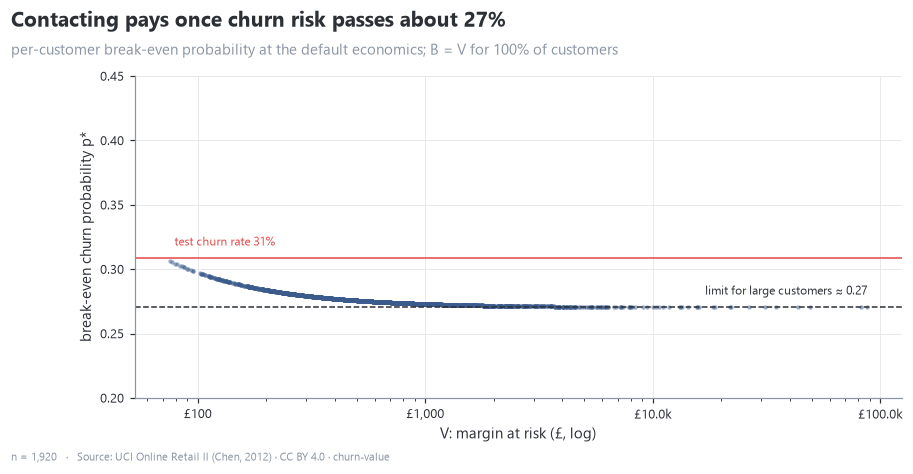

In [4]:
econ = customer_economics(econ_v, ECON)
p_star = break_even_probability(econ, ECON)
S["p_star_quantiles"] = dict(
    zip(["p10", "p50", "p90"], np.percentile(p_star, [10, 50, 90]), strict=True)
)
S["b_equals_v_share"] = float(np.mean(np.isclose(econ.benefit, econ.value)))
S["p_star_limit"] = break_even_limit(ECON)

fig, ax = plt.subplots(figsize=(9, 3.8))
order = np.argsort(econ_v)
ax.scatter(econ_v, p_star, s=8, color=NEUTRAL, alpha=0.5, lw=0)
ax.axhline(S["p_star_limit"], color=INK, lw=1, ls="--")
ax.text(
    econ_v.max(),
    S["p_star_limit"] + 0.01,
    f"limit for large customers ≈ {S['p_star_limit']:.2f}",
    ha="right",
    fontsize=8,
    color=INK,
)
ax.axhline(y_test.mean(), color=CHURN, lw=1)
ax.text(
    econ_v.min() * 1.05,
    y_test.mean() + 0.01,
    f"test churn rate {y_test.mean():.0%}",
    fontsize=8,
    color=CHURN,
)
ax.set_xscale("log")
ax.set_xlabel("V: margin at risk (£, log)")
ax.set_ylabel("break-even churn probability p*")
ax.xaxis.set_major_formatter(lambda v, _: style.gbp(v))
ax.set_ylim(0.2, 0.45)
style.headline(
    fig,
    f"Contacting pays once churn risk passes about {S['p_star_limit']:.0%}",
    "per-customer break-even probability at the default economics; B = V for "
    f"{S['b_equals_v_share']:.0%} of customers",
)
style.add_source(fig, f"n = {len(test):,}")
save(fig, "break_even")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">B4 · Ranking</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">are the right customers at the top?</span></div>

Ranking quality with 95 % confidence intervals from the customer-clustered bootstrap
(`reports/baseline_evaluation.json`), and the precision–recall curves behind PR-AUC. The
horizontal line is the base rate: a model that ranks at random sits on it.

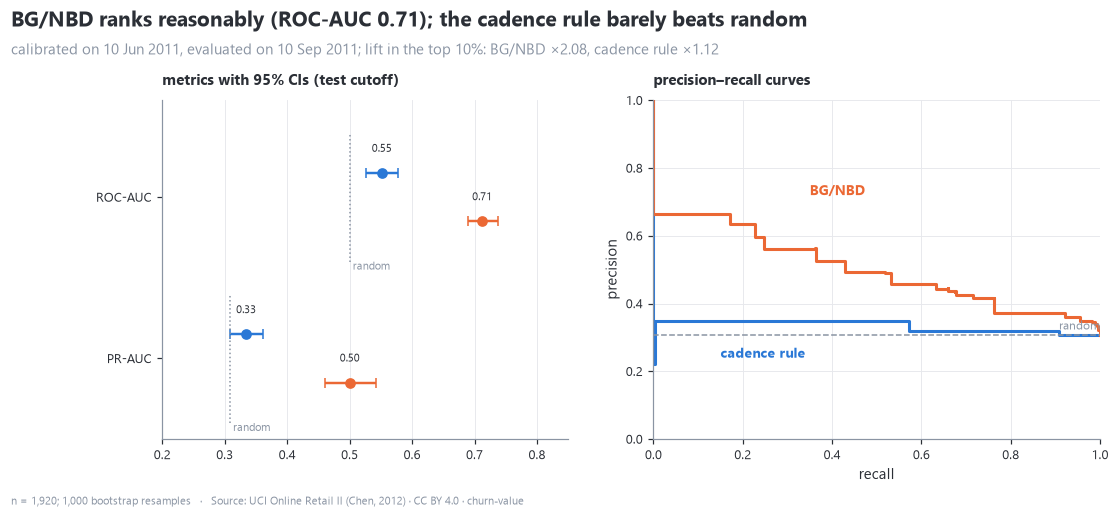

In [5]:
probabilities = {}
for name, scorer in BASELINE_SCORERS.items():
    calibrator = select_calibrator(scorer(cal), y_cal, seed=EV.seed)
    probabilities[name] = {
        "cal": calibrator.transform(scorer(cal)),
        "test": calibrator.transform(scorer(test)),
    }

metrics = pd.DataFrame(
    [
        {"model": LABELS[m], "metric": k, **v}
        for m, body in report["models"].items()
        for k, v in body["metrics"].items()
        if k in ("pr_auc", "roc_auc", "lift_at_10")
    ]
)
S["metrics"] = metrics.to_dict(orient="records")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.1]})
names = ["pr_auc", "roc_auc"]
for i, (model, color) in enumerate(
    [("cadence rule", MODEL_COLORS["cadence_rule"]), ("BG/NBD", MODEL_COLORS["bgnbd"])]
):
    part = metrics[metrics["model"] == model].set_index("metric").loc[names]
    ypos = np.arange(len(names)) + (0.15 if i == 0 else -0.15)
    ax1.errorbar(
        part["value"],
        ypos,
        xerr=[part["value"] - part["ci_low"], part["ci_high"] - part["value"]],
        fmt="o",
        color=color,
        ecolor=color,
        capsize=3,
        markersize=6,
        lw=1.6,
    )
    for yv, v in zip(ypos, part["value"], strict=True):
        ax1.text(v, yv + 0.13, f"{v:.2f}", ha="center", fontsize=7.5, color=INK)
ax1.set_yticks(range(len(names)), ["PR-AUC", "ROC-AUC"])
for row, random_value in [(0, y_test.mean()), (1, 0.5)]:  # PR-AUC: base rate; ROC-AUC: 0.5
    ax1.vlines(random_value, row - 0.4, row + 0.4, color=MUTED, lw=1, ls=":")
    ax1.text(random_value + 0.005, row - 0.45, "random", fontsize=7, color=MUTED)
ax1.set_xlim(0.2, 0.85)
ax1.set_ylim(-0.5, 1.6)
ax1.set_title("metrics with 95% CIs (test cutoff)", fontsize=9.5)
ax1.grid(axis="y", visible=False)
for name, body in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, body["test"])
    ax2.plot(recall, precision, color=MODEL_COLORS[name], lw=2, drawstyle="steps-post")
ax2.axhline(y_test.mean(), color=MUTED, lw=1, ls="--")
ax2.text(1.0, y_test.mean() + 0.015, "random", ha="right", fontsize=8, color=MUTED)
ax2.text(0.35, 0.72, "BG/NBD", color=MODEL_COLORS["bgnbd"], fontsize=9, fontweight="bold")
ax2.text(
    0.15, 0.24, "cadence rule", color=MODEL_COLORS["cadence_rule"], fontsize=9, fontweight="bold"
)
ax2.set_xlabel("recall")
ax2.set_ylabel("precision")
ax2.set_title("precision–recall curves", fontsize=9.5)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
bg = metrics[(metrics["model"] == "BG/NBD") & (metrics["metric"] == "roc_auc")].iloc[0]
lift = metrics[metrics["metric"] == "lift_at_10"].set_index("model")["value"]
style.headline(
    fig,
    f"BG/NBD ranks reasonably (ROC-AUC {bg['value']:.2f}); the cadence rule barely beats random",
    f"calibrated on 10 Jun 2011, evaluated on 10 Sep 2011; lift in the top 10%: "
    f"BG/NBD ×{lift['BG/NBD']:.2f}, cadence rule ×{lift['cadence rule']:.2f}",
)
style.add_source(fig, f"n = {len(test):,}; {EV.n_bootstrap:,} bootstrap resamples")
save(fig, "ranking")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">B5 · Calibration</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">right on June, wrong on September</span></div>

A reliability diagram groups customers by their predicted churn probability and compares it
with the share that actually churned. On the calibration cutoff the BG/NBD probabilities sit on
the diagonal — the calibrator was fitted there. On the test cutoff, three months later, they
sit well below it: the model predicts June's churn rate in September and over-predicts churn
(49 % predicted on average against 31 % observed). The ranking survived the season; the
probabilities did not.

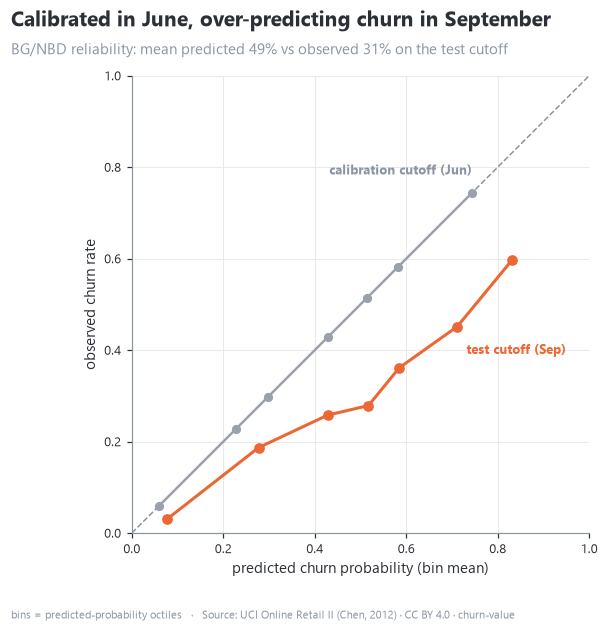

In [6]:
def reliability(p, y, n_bins=8):
    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    idx = np.clip(np.searchsorted(edges, p, side="right") - 1, 0, n_bins - 1)
    frame = pd.DataFrame({"p": p, "y": y, "bin": idx})
    return frame.groupby("bin").agg(
        predicted=("p", "mean"), observed=("y", "mean"), n=("y", "size")
    )


bg_prob = probabilities["bgnbd"]
rel_cal = reliability(bg_prob["cal"], y_cal)
rel_test = reliability(bg_prob["test"], y_test)
S["bgnbd_mean_p"] = {"calibration": bg_prob["cal"].mean(), "test": bg_prob["test"].mean()}
S["observed_rate"] = {"calibration": y_cal.mean(), "test": y_test.mean()}

fig, ax = plt.subplots(figsize=(6.2, 5.4))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.plot(rel_cal["predicted"], rel_cal["observed"], "o-", color=RETAINED, lw=1.6, markersize=5)
ax.plot(
    rel_test["predicted"],
    rel_test["observed"],
    "o-",
    color=MODEL_COLORS["bgnbd"],
    lw=2,
    markersize=6,
)
ax.text(
    rel_cal["predicted"].iloc[-1],
    rel_cal["observed"].iloc[-1] + 0.04,
    "calibration cutoff (Jun)",
    ha="right",
    fontsize=8.5,
    color=MUTED,
    fontweight="bold",
)
ax.text(
    rel_test["predicted"].iloc[-2] + 0.02,
    rel_test["observed"].iloc[-2] - 0.06,
    "test cutoff (Sep)",
    fontsize=8.5,
    color=MODEL_COLORS["bgnbd"],
    fontweight="bold",
)
ax.set_xlabel("predicted churn probability (bin mean)")
ax.set_ylabel("observed churn rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
style.headline(
    fig,
    "Calibrated in June, over-predicting churn in September",
    f"BG/NBD reliability: mean predicted {S['bgnbd_mean_p']['test']:.0%} vs "
    f"observed {y_test.mean():.0%} on the test cutoff",
)
style.add_source(fig, "bins = predicted-probability octiles")
save(fig, "reliability")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">B6 · Money</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">expected profit versus what actually happened</span></div>

Each policy contacts the customers whose expected profit is positive under its own
probabilities, and is scored on the test labels: a retained churner is worth γ·(B − CRC), an
incentive paid to a customer who would have stayed is a loss of CRC, every contact costs £1.
The oracle knows the future — it is the ceiling. Bars show the realized profit with its 95 %
bootstrap interval; hollow markers show what each model *expected* to make.

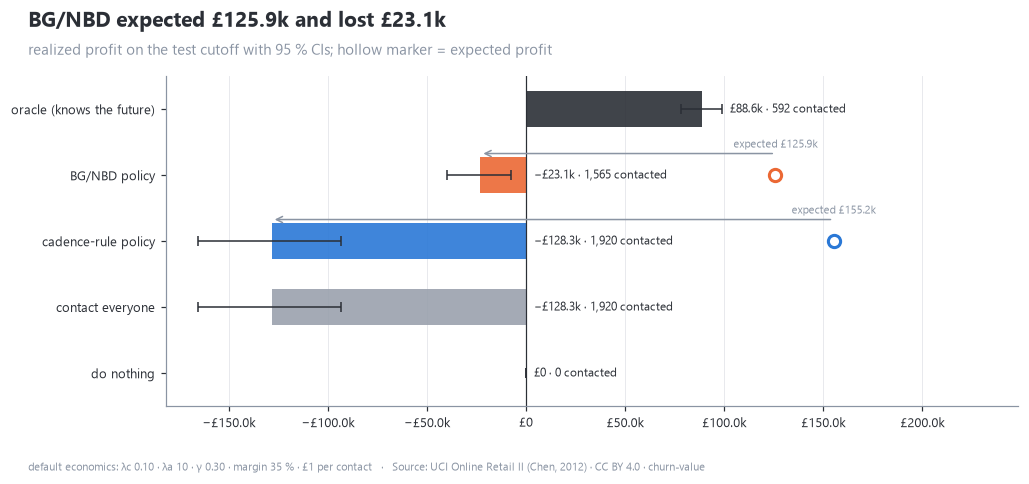

,n_contacted,expected_profit,realized_profit,realized_profit_ci_low,realized_profit_ci_high,share_of_oracle
policy,,,,,,
do_nothing,0,£0,£0,£0,£0,0%
contact_all,"1,920",—,"£-128,345","£-165,289","£-93,323",-145%
cadence_rule,"1,920","£155,221","£-128,345","£-165,289","£-93,323",-145%
bgnbd,"1,565","£125,850","£-23,067","£-39,697","£-7,762",-26%
oracle,592,—,"£88,558","£78,016","£98,844",100%


In [7]:
policies = pd.DataFrame(report["policies"]).set_index("policy")
S["policies"] = policies.to_dict(orient="index")
order = ["oracle", "bgnbd", "cadence_rule", "contact_all", "do_nothing"]
names = {
    "oracle": "oracle (knows the future)",
    "bgnbd": "BG/NBD policy",
    "cadence_rule": "cadence-rule policy",
    "contact_all": "contact everyone",
    "do_nothing": "do nothing",
}
colors = {
    "oracle": ORACLE_COLOR,
    "bgnbd": MODEL_COLORS["bgnbd"],
    "cadence_rule": MODEL_COLORS["cadence_rule"],
    "contact_all": RETAINED,
    "do_nothing": RETAINED,
}

fig, ax = plt.subplots(figsize=(10, 3.9))
y = np.arange(len(order))[::-1]
for yi, key in zip(y, order, strict=True):
    row = policies.loc[key]
    ax.barh(yi, row["realized_profit"], color=colors[key], height=0.55, alpha=0.9)
    ax.errorbar(
        row["realized_profit"],
        yi,
        xerr=[
            [row["realized_profit"] - row["realized_profit_ci_low"]],
            [row["realized_profit_ci_high"] - row["realized_profit"]],
        ],
        color=INK,
        capsize=3,
        lw=1,
    )
    if key in ("bgnbd", "cadence_rule"):
        ax.plot(
            row["expected_profit"],
            yi,
            "o",
            markerfacecolor="white",
            markeredgecolor=colors[key],
            markersize=8,
            markeredgewidth=2,
        )
        ax.annotate(
            "",
            xy=(row["realized_profit"], yi + 0.33),
            xytext=(row["expected_profit"], yi + 0.33),
            arrowprops={"arrowstyle": "->", "color": MUTED, "lw": 1},
        )
        ax.text(
            row["expected_profit"],
            yi + 0.42,
            f"expected {style.gbp(row['expected_profit'])}",
            ha="center",
            fontsize=7.5,
            color=MUTED,
        )
    label_x = max(row["realized_profit_ci_high"], 0) + 4_000
    label = f"{style.gbp(row['realized_profit'])} · {int(row['n_contacted']):,} contacted"
    ax.text(label_x, yi, label, va="center", fontsize=8, color=INK)
ax.axvline(0, color=INK, lw=0.8)
ax.set_yticks(y, [names[k] for k in order])
ax.xaxis.set_major_formatter(lambda v, _: style.gbp(v))
ax.grid(axis="y", visible=False)
ax.set_xlim(
    policies["realized_profit_ci_low"].min() * 1.1,
    max(policies["expected_profit"].max(), policies["realized_profit"].max()) * 1.6,
)
bg_row = policies.loc["bgnbd"]
style.headline(
    fig,
    f"BG/NBD expected {style.gbp(bg_row['expected_profit'])} and lost "
    f"{style.gbp(-bg_row['realized_profit'])}",
    "realized profit on the test cutoff with 95 % CIs; hollow marker = expected profit",
)
style.add_source(fig, "default economics: λc 0.10 · λa 10 · γ 0.30 · margin 35 % · £1 per contact")
save(fig, "policies")
plt.show()

money = "£{:,.0f}"
table = policies[
    [
        "n_contacted",
        "expected_profit",
        "realized_profit",
        "realized_profit_ci_low",
        "realized_profit_ci_high",
        "share_of_oracle",
    ]
]
display(
    table.style.format(
        {
            "expected_profit": money,
            "realized_profit": money,
            "realized_profit_ci_low": money,
            "realized_profit_ci_high": money,
            "share_of_oracle": "{:.0%}",
            "n_contacted": "{:,}",
        },
        na_rep="—",
    )
)

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">06 → 07, 08, 10</span></div>

**Produced** — `reports/results/06_summary.json` and the figures `06_bgnbd`,
`06_value_at_risk`, `06_break_even`, `06_ranking`, `06_reliability`, `06_policies`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>Ranking is not enough. BG/NBD ranks customers reasonably, but its probabilities, calibrated in June, over-state September's churn; the policy it drives expects a profit and realizes a loss.</li><li>The cadence rule barely beats random inside the eligible population, confirming stage 04: lateness was already used to define who is eligible.</li><li>The oracle shows the prize: a campaign aimed at exactly the right customers would make about £89k on this cutoff.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>None on the data. The bar the supervised models must clear is set: rank at least as well as BG/NBD <i>and</i> stay calibrated across seasons, measured in realized profit with its interval.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>07_model_training</b> — supervised models with the season features of stage 05, tuned with rolling-origin folds.</li><li><b>08_evaluation</b> — the same reliability test on the supervised models; <b>11_ablation</b> — the calibration fixes that do not work (same-season calibration, prior-shift correction).</li><li><b>10_business_value</b> — the economics above, explored across assumptions.</li></ul></div>

In [8]:
S.write(RESULTS)

WindowsPath('reports/results/06_summary.json')